<a href="https://colab.research.google.com/github/Daniel-Benson-Poe/DS-Unit-1-Sprint-3-Linear-Algebra/blob/master/db_LS_DS_134_Clustering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

# 1) Use the "Breast Cancer Wisconsin (Diagnostic) Data Set" from Kaggle to try and cluster types of cancer cells. 

Here's the original dataset for your reference:

<https://www.kaggle.com/uciml/breast-cancer-wisconsin-data>

## This is a supervised learning dataset

(Because it has **labels** - The "diagnosis" column.)

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA # You don't necessarily have to use this
from sklearn.cluster import KMeans # You don't necessarily have to use this
from sklearn.preprocessing import StandardScaler # You don't necessarily have to use this

df = pd.read_csv("https://raw.githubusercontent.com/ryanleeallred/datasets/master/Cancer_Cells.csv")
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Now it's an unsupervised learning dataset

(Because we've removed the diagnosis label) - Use this version.

In [66]:
df = df.drop('diagnosis', axis=1)
df.head()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Let's do it!

- You might want to do some data exploration to see if you can find specific columns that will help you find distinct clusters of cells
- You might want to use the elbow method to decide on the number of clusters to use.


In [3]:
# Let's first check the data types 
df.dtypes

id                           int64
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

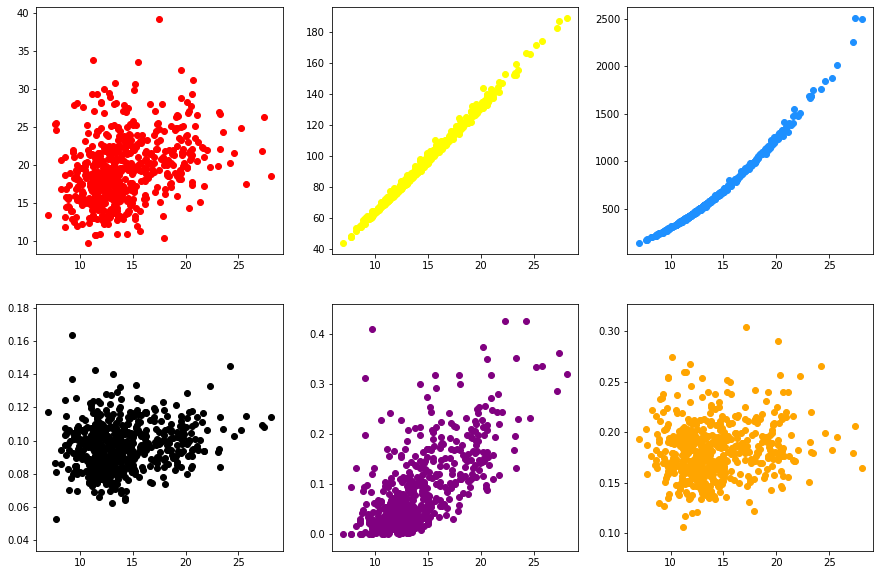

In [4]:
fig, axes = plt.subplots(2,3,figsize=(15, 10))
axes[0][0].scatter(df['radius_mean'], df['texture_mean'], c='r')
axes[0][1].scatter(df['radius_mean'], df['perimeter_mean'], c='yellow')
axes[0][2].scatter(df['radius_mean'], df['area_mean'], c='dodgerblue')
axes[1][0].scatter(df['radius_mean'], df['smoothness_mean'], c='k')
axes[1][1].scatter(df['radius_mean'], df['concavity_mean'], c='purple')
axes[1][2].scatter(df['radius_mean'], df['symmetry_mean'], c='orange');

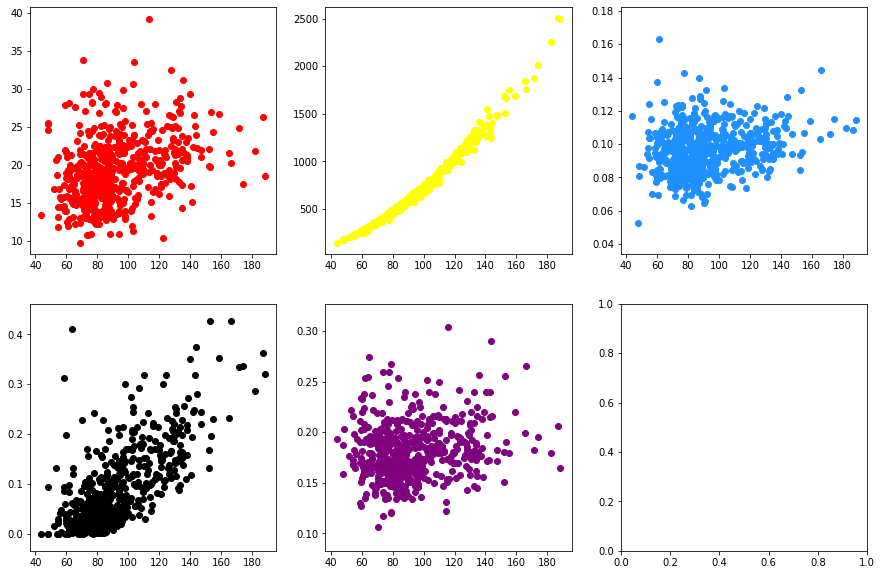

In [5]:
fig, axes = plt.subplots(2,3,figsize=(15, 10))
axes[0][0].scatter(df['perimeter_mean'], df['texture_mean'], c='r')
axes[0][1].scatter(df['perimeter_mean'], df['area_mean'], c='yellow')
axes[0][2].scatter(df['perimeter_mean'], df['smoothness_mean'], c='dodgerblue')
axes[1][0].scatter(df['perimeter_mean'], df['concavity_mean'], c='k')
axes[1][1].scatter(df['perimeter_mean'], df['symmetry_mean'], c='purple');

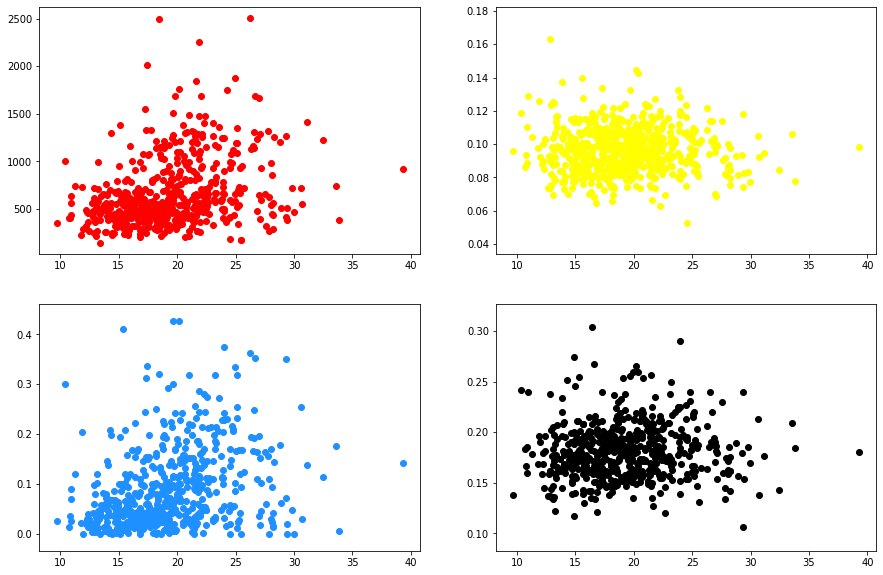

In [6]:
fig, axes = plt.subplots(2,2,figsize=(15, 10))
axes[0][0].scatter(df['texture_mean'], df['area_mean'], c='r')
axes[0][1].scatter(df['texture_mean'], df['smoothness_mean'], c='yellow')
axes[1][0].scatter(df['texture_mean'], df['concavity_mean'], c='dodgerblue')
axes[1][1].scatter(df['texture_mean'], df['symmetry_mean'], c='k')


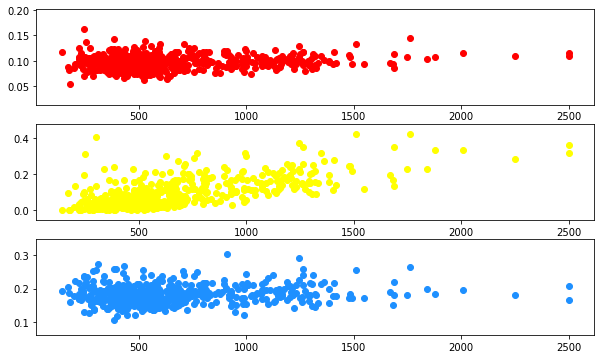

In [7]:
fig, axes = plt.subplots(3,1,figsize=(10, 6))
axes[0].scatter(df['area_mean'], df['smoothness_mean'], c='r')
axes[1].scatter(df['area_mean'], df['concavity_mean'], c='yellow')
axes[2].scatter(df['area_mean'], df['symmetry_mean'], c='dodgerblue')
plt.show()

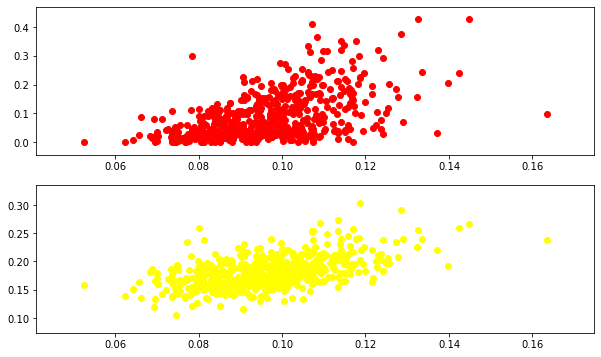

In [8]:
fig, axes = plt.subplots(2,1,figsize=(10, 6))
axes[0].scatter(df['smoothness_mean'], df['concavity_mean'], c='r')
axes[1].scatter(df['smoothness_mean'], df['symmetry_mean'], c='yellow')
plt.show()


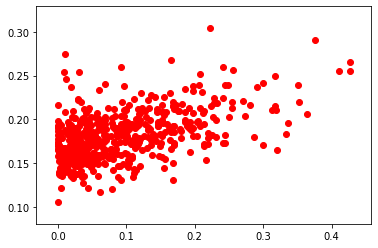

In [9]:
plt.scatter(df['concavity_mean'], df['symmetry_mean'], c='r');

In [10]:
# Check for nulls
df.isnull().sum()

id                           0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed: 32                569
dtype: i

In [11]:
# let's look closer at that unnamed column
df['Unnamed: 32'].values

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

In [12]:
# Gross. Let's drop it.
df = df.drop('Unnamed: 32', axis=1)
# Also, for our purposes the id column is pointless so let's remove it for now
df = df.drop('id', axis=1)
print(df.head())
df.isnull().sum()

   radius_mean  texture_mean  ...  symmetry_worst  fractal_dimension_worst
0        17.99         10.38  ...          0.4601                  0.11890
1        20.57         17.77  ...          0.2750                  0.08902
2        19.69         21.25  ...          0.3613                  0.08758
3        11.42         20.38  ...          0.6638                  0.17300
4        20.29         14.34  ...          0.2364                  0.07678

[5 rows x 30 columns]


radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

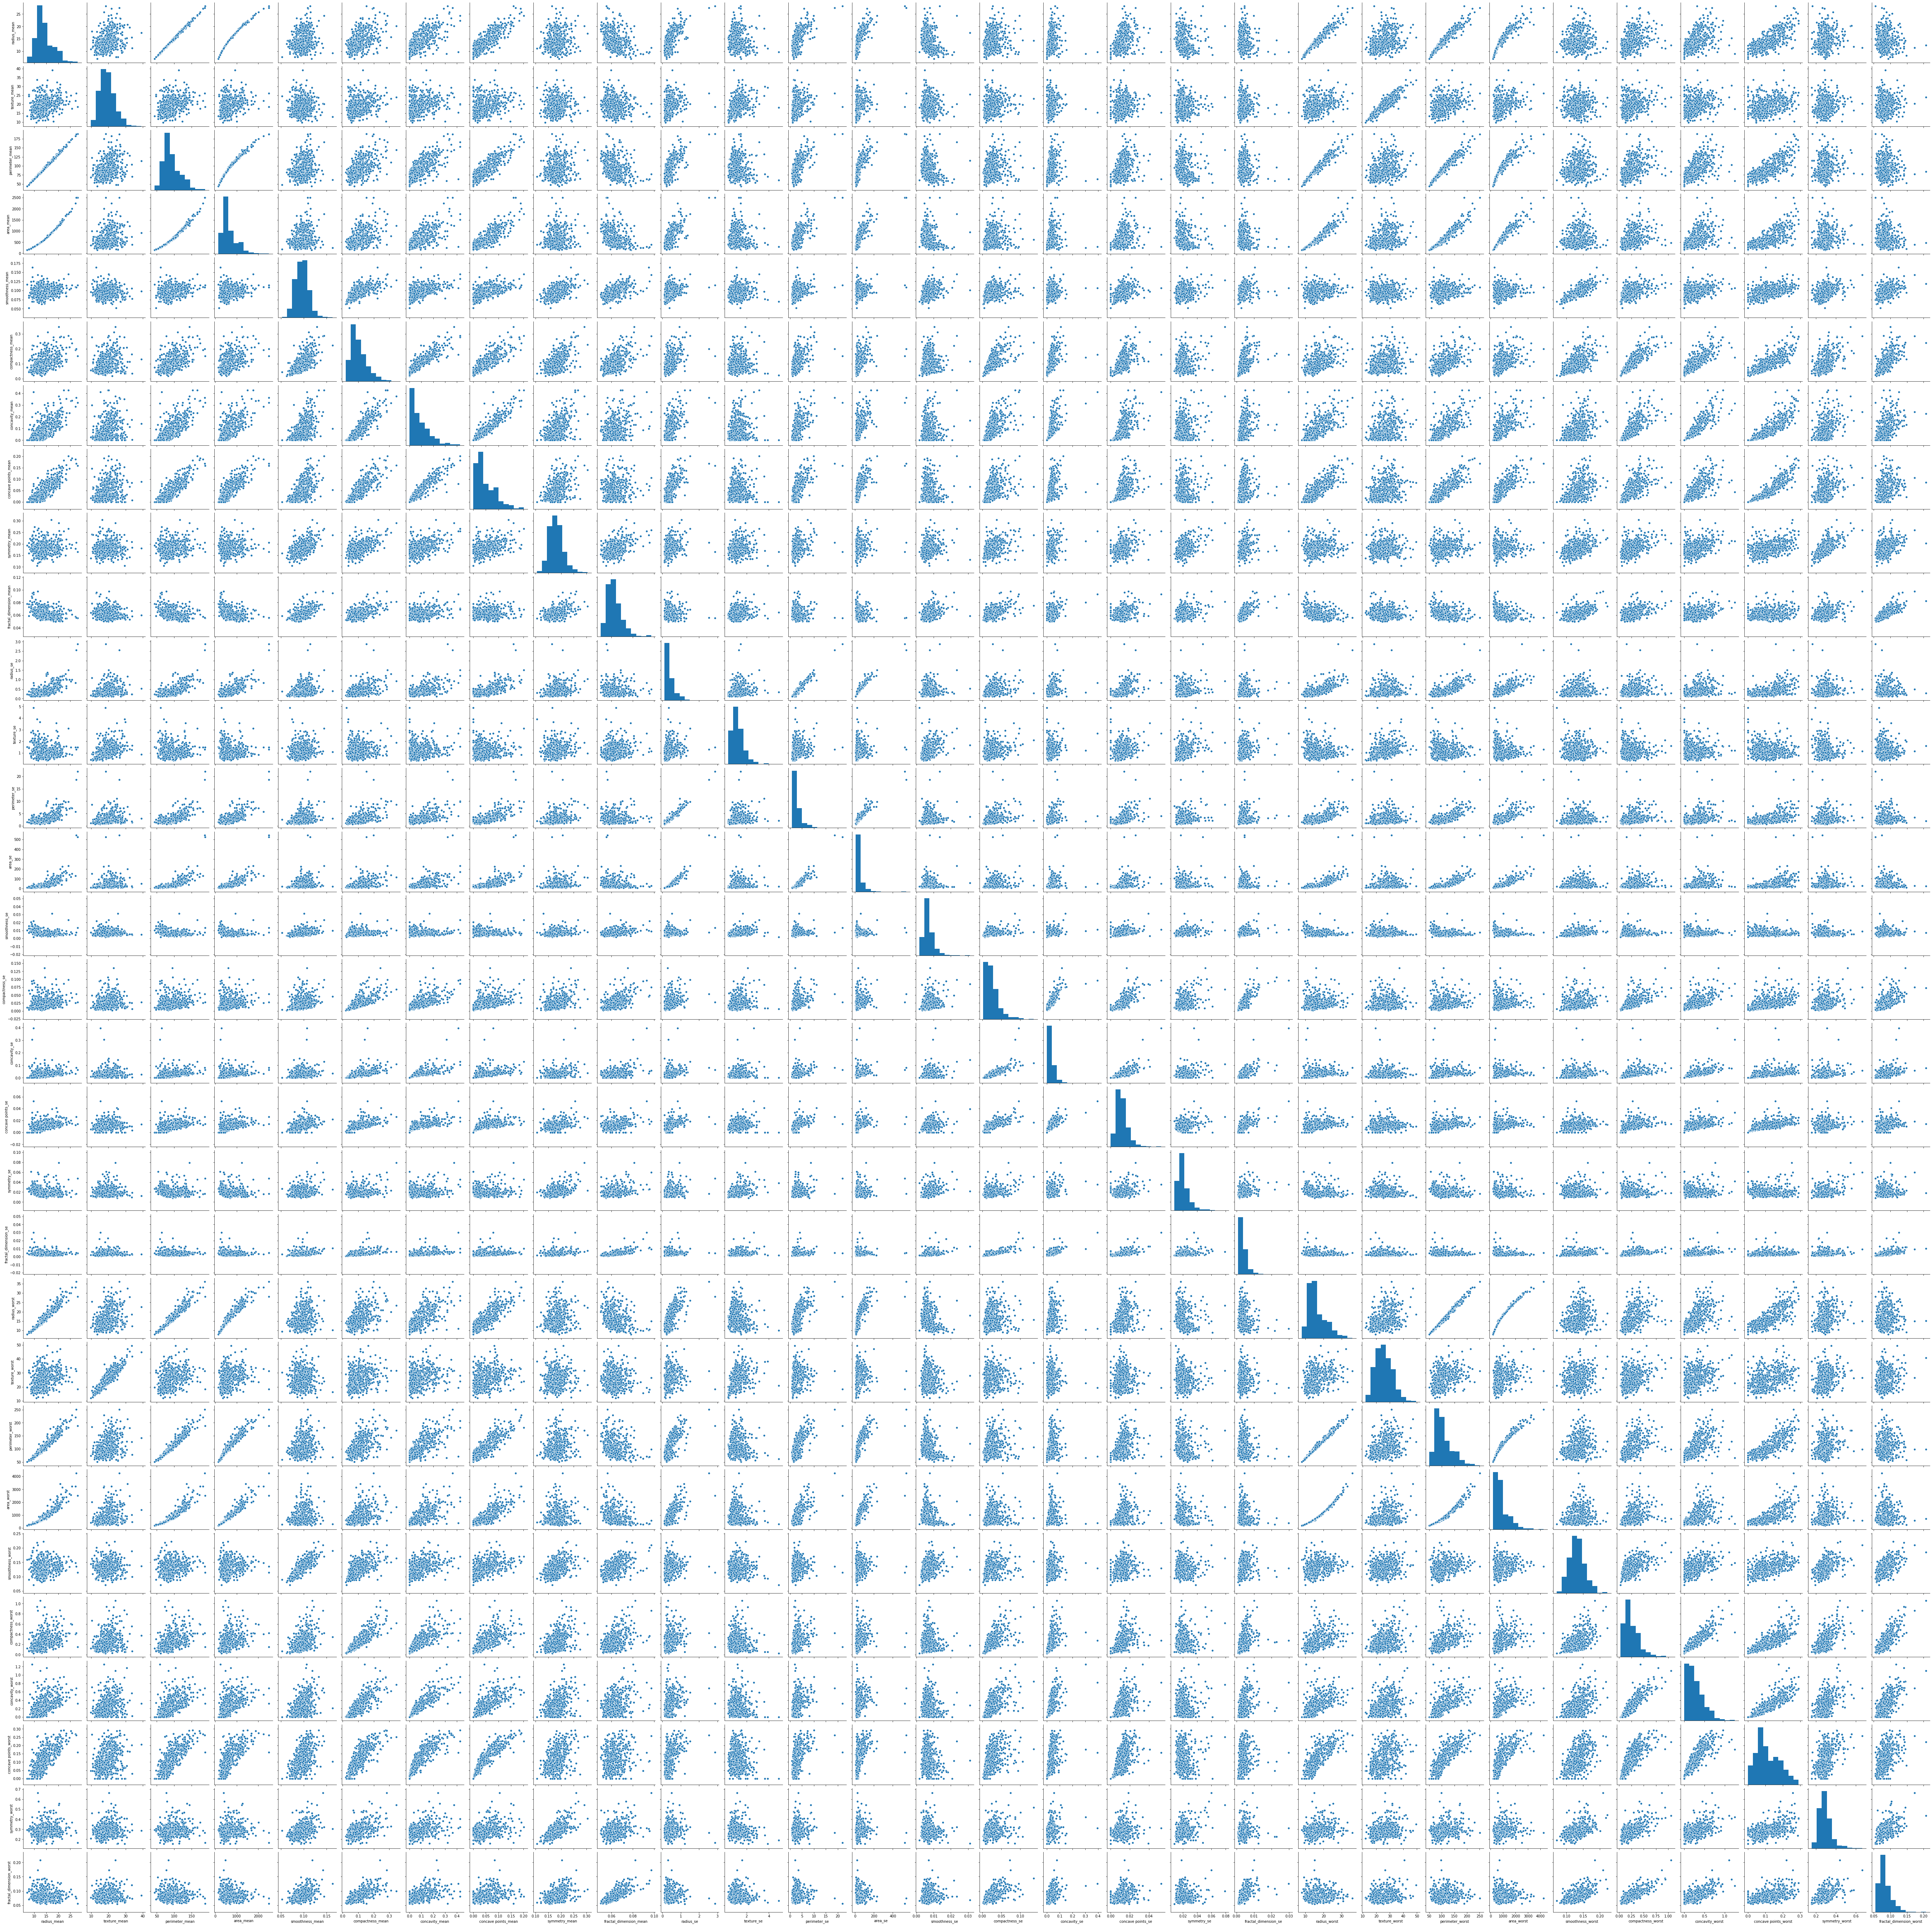

In [0]:
# Let's use seaborn plotting to get a decent look at a number of plots
import seaborn as sns
sns.pairplot(df)

In [0]:
# Now let's create our elbow graph!
sum_of_squared_distance = []
K = range(1, 15)
for k in K:
  km = KMeans(n_clusters=k)
  km = km.fit(df)
  sum_of_squared_distance.append(km.inertia_)

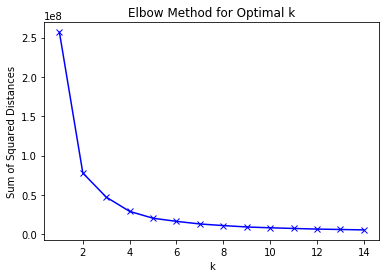

In [14]:
# Now plot our elbow graph
plt.plot(K, sum_of_squared_distance, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal k')
plt.show()

In [0]:
# According to the elbow graph the optimal k is going to be 2
# We also have a whole lot of columns to compare, so let's use PCA to bring that number down to 2
# Instantiate sklearn class
scaler = StandardScaler()

In [0]:
# Standardize dataset
scaled_data = scaler.fit_transform(df)

In [17]:
# Look at first five lists of data
scaled_data[:5]

array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

In [18]:
# Create feature names to call into a future dataframe
features = list(df.columns)
features

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [19]:
# Now let's turn it back into a dataframe
df_scaled = pd.DataFrame(scaled_data, columns=features)
df_scaled.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [20]:
# Check our means
df_scaled.mean()

radius_mean               -1.256562e-16
texture_mean               1.049736e-16
perimeter_mean            -1.272171e-16
area_mean                 -1.900452e-16
smoothness_mean            1.490704e-16
compactness_mean           2.544342e-16
concavity_mean            -1.338511e-16
concave points_mean       -8.429110e-17
symmetry_mean              2.081912e-16
fractal_dimension_mean     5.408679e-16
radius_se                  2.475807e-16
texture_se                -9.912009e-17
perimeter_se              -2.968237e-16
area_se                   -1.088760e-16
smoothness_se              4.426014e-16
compactness_se             1.958988e-16
concavity_se               1.678017e-16
concave points_se          2.185325e-17
symmetry_se                1.523874e-16
fractal_dimension_se      -5.658430e-17
radius_worst              -7.988142e-16
texture_worst             -1.834112e-17
perimeter_worst           -4.015534e-16
area_worst                -2.848727e-17
smoothness_worst          -2.189227e-16


In [21]:
# Check our standard deviations
df_scaled.std()

radius_mean                1.00088
texture_mean               1.00088
perimeter_mean             1.00088
area_mean                  1.00088
smoothness_mean            1.00088
compactness_mean           1.00088
concavity_mean             1.00088
concave points_mean        1.00088
symmetry_mean              1.00088
fractal_dimension_mean     1.00088
radius_se                  1.00088
texture_se                 1.00088
perimeter_se               1.00088
area_se                    1.00088
smoothness_se              1.00088
compactness_se             1.00088
concavity_se               1.00088
concave points_se          1.00088
symmetry_se                1.00088
fractal_dimension_se       1.00088
radius_worst               1.00088
texture_worst              1.00088
perimeter_worst            1.00088
area_worst                 1.00088
smoothness_worst           1.00088
compactness_worst          1.00088
concavity_worst            1.00088
concave points_worst       1.00088
symmetry_worst      

In [22]:
# Now apply PCA to our dataframe
pca = PCA(n_components=2)
pca_features = pca.fit_transform(df_scaled)
pca_features[:5]

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       [ 7.1229532 , 10.27558912],
       [ 3.93530207, -1.94807157]])

In [23]:
# How much variance4 did each principal component explain?
pca.explained_variance_ratio_

array([0.44272026, 0.18971182])

In [24]:
# How much total variance did we explain?
sum(pca.explained_variance_ratio_)

0.6324320765155946

In [25]:
# How much information did we lose?
1 - sum(pca.explained_variance_ratio_)

0.36756792348440537

In [26]:
# Let's turn that into a dataframe
df_pca = pd.DataFrame(pca_features, columns=['comp_1', 'comp_1'])
df_pca.head()

,comp_1,comp_1
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


In [27]:
# For curiosity's sake let's change our n_components value
pca = PCA(n_components=7)
# Apply pca to data
pca_features = pca.fit_transform(df_scaled)
pca_features[:5]

array([[ 9.19283683,  1.94858307, -1.1231662 ,  3.63373087, -1.19511042,
         1.41142365,  2.15940509],
       [ 2.3878018 , -3.76817174, -0.52929267,  1.11826399,  0.62177512,
         0.02865702,  0.01334298],
       [ 5.73389628, -1.0751738 , -0.55174761,  0.91208301, -0.17708586,
         0.54145268, -0.6681571 ],
       [ 7.1229532 , 10.27558912, -3.23278954,  0.15254715, -2.96087831,
         3.05342198,  1.42990432],
       [ 3.93530207, -1.94807157,  1.38976675,  2.94063898,  0.5467474 ,
        -1.22649526, -0.93622624]])

In [28]:
# How much variance did each principal component explain?
print(pca.explained_variance_ratio_, '\n\n')
# How much total variance did we explain?
print(sum(pca.explained_variance_ratio_), '\n\n')
# How much information did we lose?
print(1 - sum(pca.explained_variance_ratio_))

[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734] 


0.9100953006926163 


0.08990469930738365


In [29]:
# Turn that into a dataframe
df_pca = pd.DataFrame(pca_features, columns=['comp_1', 'comp_2', 'comp_3', 'comp_4', 'comp_5', 'comp_6', 'comp_7'])
df_pca.head()

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159405
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028657,0.013343
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541453,-0.668157
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429904
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936226


In [0]:
# We can clearly see that as we increase the n_components in our PCA we lose
# less and less of our data; however, we slowly begin to run into the same
# problem we had to begin with: too many columns.

In [0]:
# Now it's time to apply clustering to the data!
# Initialize instance of KMeans from sklearn
k = 2
model = KMeans(n_clusters=k, max_iter=1)

In [32]:
# Fit model to our sliced dataframe
model.fit(df_pca.values)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=1,
       n_clusters=2, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [0]:
# Assign predicted clusters back to dataframe
df_pca['cluster'] = model.labels_

In [0]:
# Get centroids
centroids = model.cluster_centers_

In [35]:
# Turn them into dataframe
cluster_centers = pd.DataFrame(centroids)
cluster_centers.head()

,0,1,2,3,4,5,6
0,4.240284,-0.278262,-0.211315,-0.145833,-0.026717,0.078422,-0.072238
1,-2.210843,0.145083,0.110178,0.076036,0.013930,-0.040888,0.037664


In [0]:
# Set up colors for plotting
base_colors = ['gold', 'silver']
colors = [base_colors[centroid] for centroid in model.labels_]

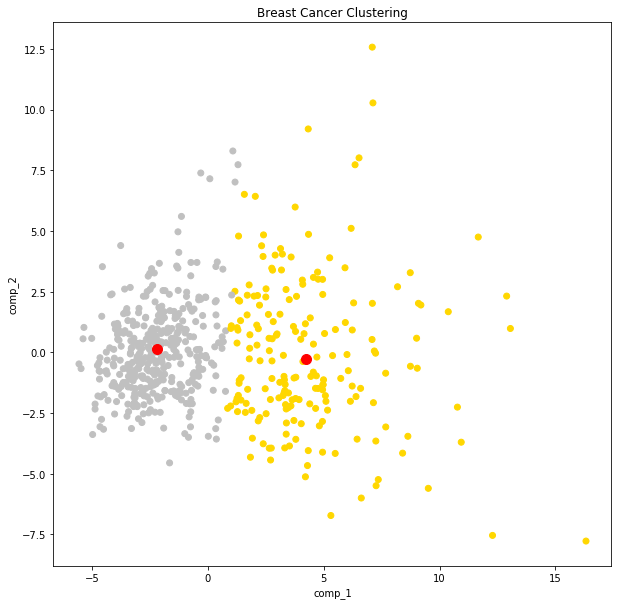

In [37]:
# Plot scatter of our points with calculated centroids
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(df_pca['comp_1'], df_pca['comp_2'], c=colors)
ax.scatter(cluster_centers[0], cluster_centers[1], c='r', s=100)
plt.xlabel('comp_1')
plt.ylabel('comp_2')
plt.title('Breast Cancer Clustering')
plt.show()

## Check you work: 

This is something that in a truly unsupervised learning situation **WOULD NOT BE POSSIBLE**. But for educational purposes go back and grab the true diagnosis column (label) from the original dataset. Take your cluster labels and compare them to the original diagnosis column. You can make scatterplots for each to see how they compare or you can calculate a percent accuracy score like: 
\begin{align}
\frac{\text{Num Correct Labels}}{\text{Num Total Observations}}
\end{align}

In [38]:
# Read in the dataset
df = pd.read_csv("https://raw.githubusercontent.com/ryanleeallred/datasets/master/Cancer_Cells.csv")
print(df.shape)
print(df.head())
df['diagnosis'].value_counts()

(569, 33)
         id diagnosis  ...  fractal_dimension_worst  Unnamed: 32
0    842302         M  ...                  0.11890          NaN
1    842517         M  ...                  0.08902          NaN
2  84300903         M  ...                  0.08758          NaN
3  84348301         M  ...                  0.17300          NaN
4  84358402         M  ...                  0.07678          NaN

[5 rows x 33 columns]


B    357
M    212
Name: diagnosis, dtype: int64

In [39]:
# Let's add the diagnosis column to our pca column
df_pca['diagnosis'] = df['diagnosis']
df_pca.head()

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,cluster,diagnosis
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159405,0,M
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028657,0.013343,0,M
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541453,-0.668157,0,M
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429904,0,M
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936226,0,M


In [40]:
# Check to ensure there aren't any random spaces in the values
print(df_pca['diagnosis'][0])
df_pca['diagnosis'][527]

M


'B'

In [41]:
# Convert diagnosis column to numeric values 0s and 1s
df_pca['diagnosis'] = df_pca['diagnosis'].replace({'M':0, 'B':1})
df_pca.head()

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,cluster,diagnosis
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159405,0,0
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028657,0.013343,0,0
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541453,-0.668157,0,0
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429904,0,0
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936226,0,0


In [42]:
# Check that the column converted correctly
print(df_pca['diagnosis'].head(10))
print(df_pca['diagnosis'].tail(10))
print(df['diagnosis'].head(10))
print(df['diagnosis'].tail(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: diagnosis, dtype: int64
559    1
560    1
561    1
562    0
563    0
564    0
565    0
566    0
567    0
568    1
Name: diagnosis, dtype: int64
0    M
1    M
2    M
3    M
4    M
5    M
6    M
7    M
8    M
9    M
Name: diagnosis, dtype: object
559    B
560    B
561    B
562    M
563    M
564    M
565    M
566    M
567    M
568    B
Name: diagnosis, dtype: object


In [43]:
# Look at the first five rows of dataframe
df_pca.head()

,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,cluster,diagnosis
0,9.192837,1.948583,-1.123166,3.633731,-1.195110,1.411424,2.159405,0,0
1,2.387802,-3.768172,-0.529293,1.118264,0.621775,0.028657,0.013343,0,0
2,5.733896,-1.075174,-0.551748,0.912083,-0.177086,0.541453,-0.668157,0,0
3,7.122953,10.275589,-3.232790,0.152547,-2.960878,3.053422,1.429904,0,0
4,3.935302,-1.948072,1.389767,2.940639,0.546747,-1.226495,-0.936226,0,0


In [44]:
df['diagnosis'] = df['diagnosis'].replace({'M':0, 'B':1})
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,0,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,0,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,0,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,0,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


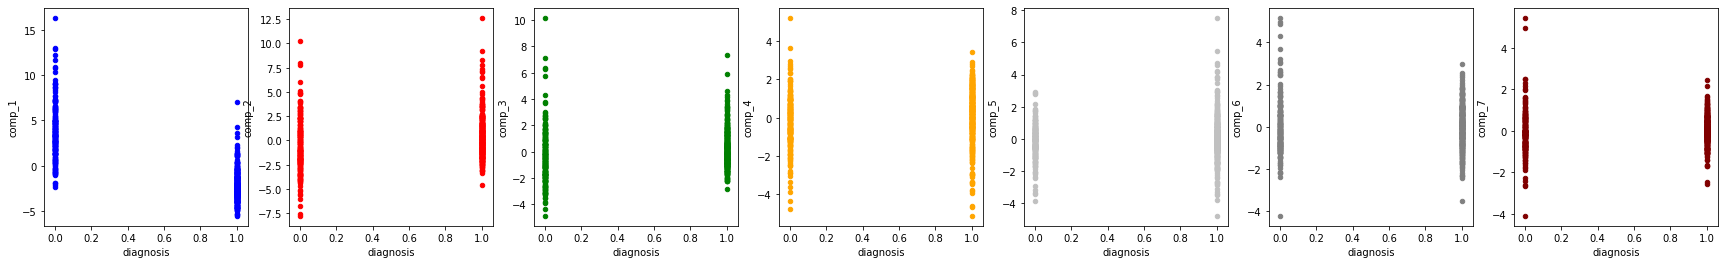

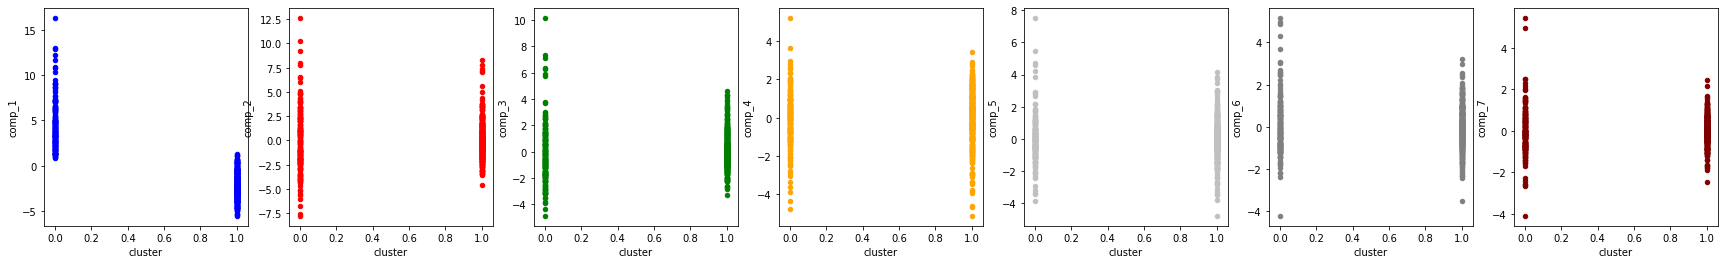

In [45]:
# Let's do some graphing now!
fig, ax = plt.subplots(ncols=7, figsize=(30,4))
df_pca.plot.scatter(x='diagnosis', y='comp_1', c='blue', ax=ax[0])
df_pca.plot.scatter(x='diagnosis', y='comp_2', c='red', ax=ax[1])
df_pca.plot.scatter(x='diagnosis', y='comp_3', c='green', ax=ax[2])
df_pca.plot.scatter(x='diagnosis', y='comp_4', c='orange', ax=ax[3])
df_pca.plot.scatter(x='diagnosis', y='comp_5', c='silver', ax=ax[4])
df_pca.plot.scatter(x='diagnosis', y='comp_6', c='grey', ax=ax[5])
df_pca.plot.scatter(x='diagnosis', y='comp_7', c='maroon', ax=ax[6])

fig, ax = plt.subplots(ncols=7, figsize=(30,4))
df_pca.plot.scatter(x='cluster', y='comp_1', c='blue', ax=ax[0])
df_pca.plot.scatter(x='cluster', y='comp_2', c='red', ax=ax[1])
df_pca.plot.scatter(x='cluster', y='comp_3', c='green', ax=ax[2])
df_pca.plot.scatter(x='cluster', y='comp_4', c='orange', ax=ax[3])
df_pca.plot.scatter(x='cluster', y='comp_5', c='silver', ax=ax[4])
df_pca.plot.scatter(x='cluster', y='comp_6', c='grey', ax=ax[5])
df_pca.plot.scatter(x='cluster', y='comp_7', c='maroon', ax=ax[6])

plt.show()

In [0]:
# For practice let's experiment with our n_component
# For the experimentation, I feel throwing together a 
# few functions will make things easier. Let's get started! 

In [52]:
for num in range(2):
  print(num)

0
1


In [0]:
# Function that applies PCA to dataset
def apply_PCA(ncomp, scaled_df):
  df_pca_columns = [] # Creates empty list for use in column names later on
  pca = PCA(n_components=ncomp) # Instantiates pca and sets n_components
  pca_features = pca.fit_transform(scaled_df) # Applies pca to dataframe
  pca_variance_ratio = pca.explained_variance_ratio_ # Returns the variance ratio
  pca_total_variance = sum(pca_variance_ratio) # Returns total variance
  pca_lost_info = 1 - pca_total_variance # Returns percent of lost info from dataframe
  for num in range(ncomp):
    df_pca_columns.append('comp_' + str(num+1))
  df_pca = pd.DataFrame(pca_features, columns=df_pca_columns) # Converts our PCA list to a dataframe
  return df_pca, pca_variance_ratio, pca_total_variance, pca_lost_info

In [0]:
# Function that applies clustering to our data
def apply_clustering(k, pca_data_frame, maxiter=1):
  model = KMeans(n_clusters=k, max_iter=maxiter) # Initialize KMeans class
  model.fit(pca_data_frame.values) # Fit model to our PCA data frame
  model_labels = model.labels_ # Assign clusters to a new column in our dataframe
  pca_data_frame['cluster'] = model_labels # Create our centroids
  cc = pd.DataFrame(centroids) # Set our centroids into a dataframe
  return pca_data_frame, centroids, cc, model_labels

In [0]:
# Function that plots our points with our centroids
def point_cluster_plotter(pca_dataframe, ncomp, model_labels, cc):
  color_list = [(random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random()),
                (random.random(), random.random(), random.random())]
  base_colors = []
  for num in range(ncomp):
    base_colors.append(color_list[num])
  colors = [base_colors[centroid] for centroid in model_labels]
  fig, ax = plt.subplots(figsize=(7, 6))
  count = 1
  while count <= ncomp:
    ax.scatter(pca_dataframe['comp_'+str(count)], pca_dataframe['comp_'+str(count+1)], c=colors)
    count += 2
  ax.scatter(cc[0], cc[1], c='k', s=100)
  plt.show()

In [0]:
# Let's check to make sure our functions work with an example we have
# already looked into

In [0]:
# First apply pca
pca_data = apply_PCA(2, df_scaled)
pca_df = pca_data[0]
variance_ratio = pca_data[1]
total_variance = pca_data[2]
lost_info = pca_data[3]

In [144]:
pca_df.head()

,comp_1,comp_2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


In [0]:
# Now apply clustering
pca_cluster = apply_clustering(2, pca_df)
pca_labels = pca_cluster[3]
pca_cc = pca_cluster[2]

In [146]:
pca_df = pca_cluster[0]
pca_df.head()

,comp_1,comp_2,cluster
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


In [147]:
pca_df.columns[2]

'cluster'

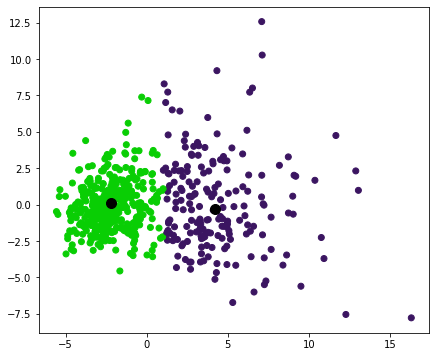

In [150]:
# Finally, plot the points and clusters
point_cluster_plotter(pca_df, 2, pca_labels, pca_cc)

In [0]:
 # Perfect! Now let's do some experimenting with other ncomps
# First, apply pca
pca_data = apply_PCA(4, df_scaled)
pca_df = pca_data[0]
variance_ratio = pca_data[1]
total_variance = pca_data[2]
lost_info = pca_data[3]

In [155]:
# Look into that 
print(total_variance, lost_info)

0.7923850582443946 0.20761494175560535


In [156]:
pca_df.head()

,comp_1,comp_2,comp_3,comp_4
0,9.192837,1.948583,-1.123168,3.633725
1,2.387802,-3.768172,-0.529292,1.118264
2,5.733896,-1.075174,-0.551747,0.912086
3,7.122953,10.275589,-3.232790,0.152545
4,3.935302,-1.948072,1.389767,2.940642


In [0]:
# Clusters
pca_cluster = apply_clustering(2, pca_df)
pca_df = pca_cluster[0]
pca_df.head()
pca_labels = pca_cluster[3]
pca_cc = pca_cluster[2]

In [164]:
pca_df.head()

,comp_1,comp_2,comp_3,comp_4,cluster
0,9.192837,1.948583,-1.123168,3.633725,0
1,2.387802,-3.768172,-0.529292,1.118264,0
2,5.733896,-1.075174,-0.551747,0.912086,0
3,7.122953,10.275589,-3.232790,0.152545,0
4,3.935302,-1.948072,1.389767,2.940642,0


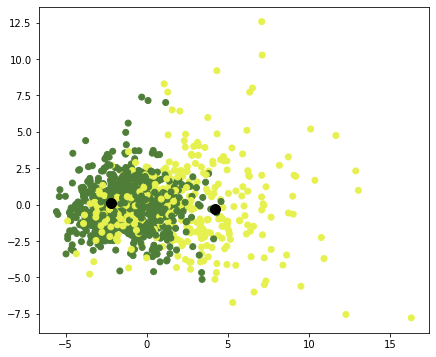

In [166]:
# Plot
point_cluster_plotter(pca_df, 4, pca_labels, pca_cc)

In [0]:
# It works, though we can clearly see that the data works better with only 2 comps

# 2) Perform PCA on your dataset first and *then* use k-means clustering. 

- You need to standardize your data before PCA.
- First try clustering just on PC1 and PC2 so that you can make a scatterplot of your clustering.
- Then use use a scree plot to decide how many principal components to include in your clustering, and use however many principal components you need in order to retain 90% of the variation of the original dataset



In [0]:
##### Your Code Here #####

## Check your work: 

- Compare your PC1, PC2 clustering scatterplot to the clustering scatterplots you made on the raw data
- Calculate accuracy scores for both the PC1,PC2 Principal component clustering and the 90% of explained variance clustering.

How do your accuracy scores -when preprocessing the data with PCA- compare to the accuracy when simply clustering on the raw data?

# Stretch Goals:

- Study for the Sprint Challenge
- Work on your Data Storytelling Project